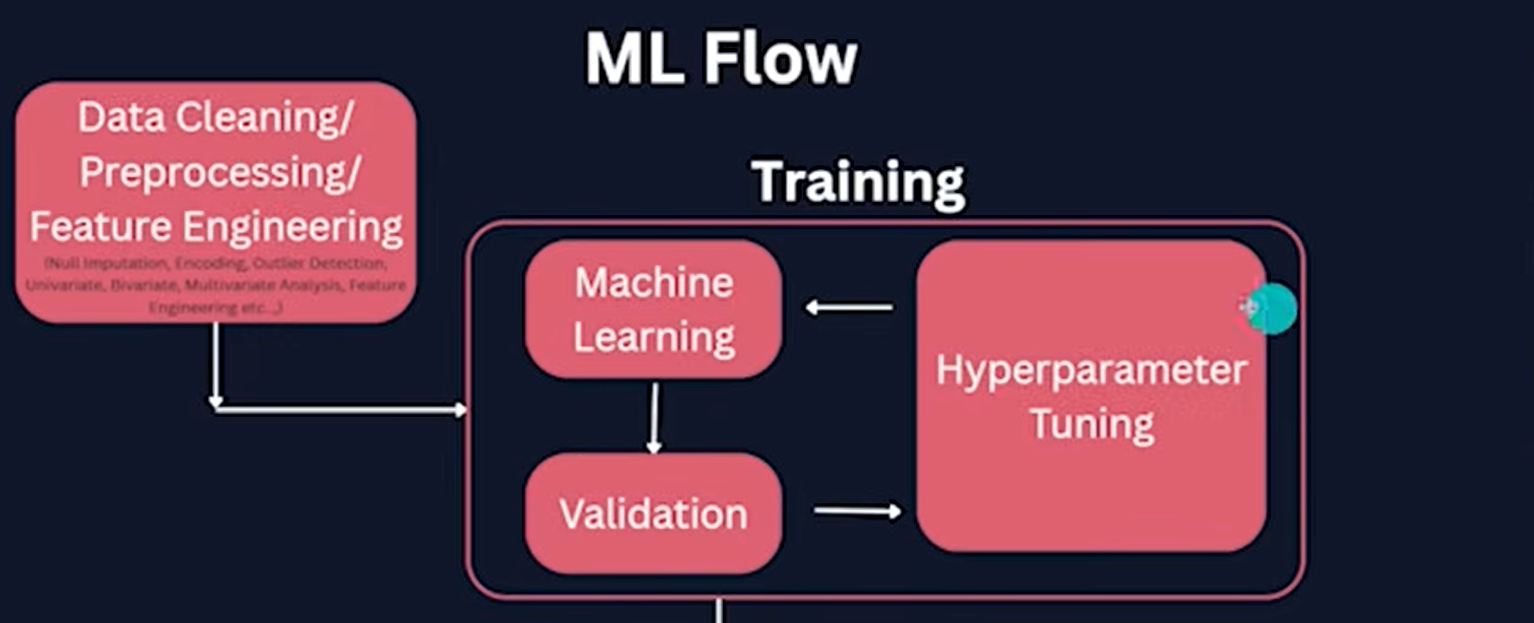

# Can we predecit whether a Loan can be approved or not

# Features:
1.   Age
2.   Income
3.   Loan_Amount
4.   Credit_Score
5.   Employment_Type
6.   Loan_Approved



Target:Approved or Rejected




In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/loan_dataset.csv')

In [ ]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,19790.0,52837,400,Self-Employed,0
1,49,41911.0,265550,307,Freelancer,0
2,35,64458.0,278680,499,Salaried,1
3,63,39363.0,33541,804,Salaried,1
4,28,35049.0,84083,386,Salaried,1
...,...,...,...,...,...,...
995,53,40227.0,101722,515,Salaried,1
996,22,20978.0,445900,737,Self-Employed,0
997,34,36991.0,35111,458,Freelancer,0
998,60,32153.0,68936,788,NaN,1


In [ ]:
#its check whethever the Null values is Available or Not
#sum() is used for to count the Null Values
df.isna().sum()

,0
Age,0
Income,50
Loan_Amount,0
Credit_Score,0
Employment_Type,50
Loan_Approved,0


In [ ]:
#check the size of the data
len(df)

1000

In [ ]:
#To calculating mean for Null Imputation
mu=df['Income'].mean()
mu

np.float64(48402.81157894737)

In [ ]:
mod=df['Employment_Type'].mode()[0]    #0->Position
mod

'Salaried'

In [ ]:
#to identify the number of Categories
df['Employment_Type'].value_counts()

,count
Employment_Type,
Salaried,450
Self-Employed,245
Business,152
Freelancer,103


In [ ]:
#To calculating mode for Categorical Variables
#to create a seperate data frame for highly repeated value
mod=df['Employment_Type'].mode()    #0->Position
mod

,Employment_Type
0,Salaried


In [ ]:
#Null Imputation technique
#one of the method is to calculating the Average
#Another one suppose its an Categorical means You have use the most repeated ans

df['Income'] = df['Income'].fillna(mu)
df['Employment_Type'] = df['Employment_Type'].fillna(mod)


In [ ]:
mod = df['Employment_Type'].mode()[0]   # extract mode first
df['Employment_Type'] = df['Employment_Type'].fillna(mod)  # then fill

In [ ]:
#Again we checking the null values
df.isna().sum()

,0
Age,0
Income,0
Loan_Amount,0
Credit_Score,0
Employment_Type,0
Loan_Approved,0


In [ ]:
#Encoding
#We can use the Scikit-Learn Package for both Encoding and ML
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Employment_Type'] = le.fit_transform(df['Employment_Type'])


In [ ]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,19790.0,52837,400,3,0
1,49,41911.0,265550,307,1,0
2,35,64458.0,278680,499,2,1
3,63,39363.0,33541,804,2,1
4,28,35049.0,84083,386,2,1
...,...,...,...,...,...,...
995,53,40227.0,101722,515,2,1
996,22,20978.0,445900,737,3,0
997,34,36991.0,35111,458,1,0
998,60,32153.0,68936,788,2,1


In [ ]:
le.classes_

array(['Business', 'Freelancer', 'Salaried', 'Self-Employed'],
      dtype=object)

In [ ]:
x= df.drop("Loan_Approved",axis = 1)  #feature
y= df["Loan_Approved"]  #target

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)  #0.2 means to reserve 20% of data for test

In [ ]:
#x_train->Feature
#y_train->Target
#Prediction
#x_test->Feature
#y_test->Target

In [ ]:
from sklearn.linear_model import LRegression

lr=LogisticRegression()
#lr=LogisticRegression(max_iter=2000)
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
y_pred

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0])

In [ ]:
y_test

,Loan_Approved
31,1
117,0
322,1
382,1
565,1
...,...
276,0
660,1
396,1
513,0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.20      0.61      0.30        23
           1       0.93      0.69      0.79       177

    accuracy                           0.68       200
   macro avg       0.57      0.65      0.55       200
weighted avg       0.85      0.68      0.74       200



### Visualizing Actual vs. Predicted Loan Approvals

This graph helps us compare what actually happened with loan approvals to what our model predicted. We'll use bar charts to show the counts of 'Approved' (represented as 1) and 'Rejected' (represented as 0) loans.

In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Age vs Income')

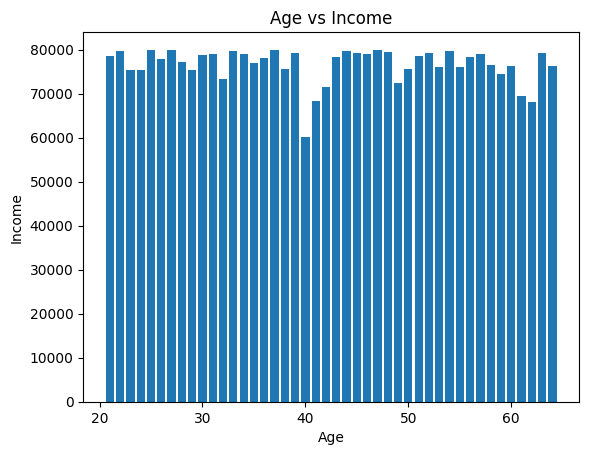

In [ ]:
plt.bar(df["Age"],df["Income"])

# Labels and title
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age vs Income")

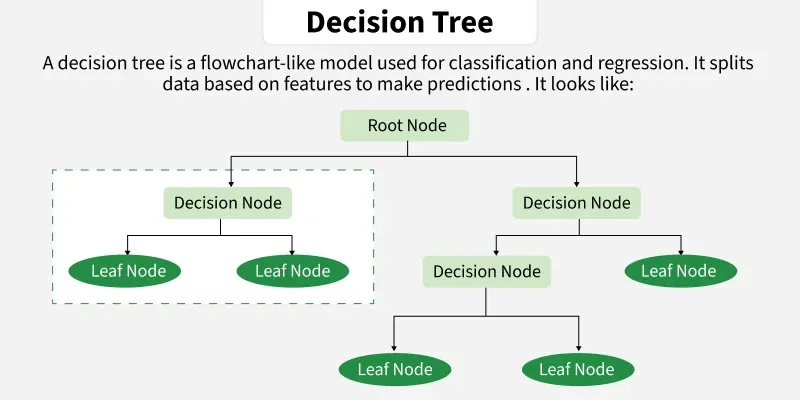

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42) # Using a random_state for reproducibility
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(x_test)

print(classification_report(y_pred_rf, y_test))

              precision    recall  f1-score   support

           0       0.41      0.55      0.47        51
           1       0.82      0.72      0.77       149

    accuracy                           0.68       200
   macro avg       0.62      0.64      0.62       200
weighted avg       0.72      0.68      0.69       200



# Based on these reports, the Random Forest model seems to have a more balanced performance overall, especially in identifying both types of loans, though both models have areas for improvement, particularly with class 0 predictions.